In [1]:
import requests
import pandas as pd
import json

# Load documents from local file
with open('documents-with-ids.json', 'r') as f:
    documents = json.load(f)

# Load ground truth data
df_ground_truth = pd.read_csv('ground-truth-data.csv')
df_ground_truth = df_ground_truth[df_ground_truth.course == 'machine-learning-zoomcamp']
ground_truth = df_ground_truth.to_dict(orient='records')

In [2]:

documents[10]

{'text': 'It depends on your background and previous experience with modules. It is expected to require about 5 - 15 hours per week. [source1] [source2]\nYou can also calculate it yourself using this data and then update this answer.',
 'section': 'General course-related questions',
 'question': 'Course - \u200b\u200bHow many hours per week am I expected to spend on this  course?',
 'course': 'data-engineering-zoomcamp',
 'id': 'ea739c65'}

In [3]:
ground_truth[10]

{'question': 'Are sessions recorded if I miss one?',
 'course': 'machine-learning-zoomcamp',
 'document': '5170565b'}

In [4]:
doc_idx = {d['id']: d for d in documents}
doc_idx['5170565b']['text']

'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.'

Index data

In [5]:
from sentence_transformers import SentenceTransformer

model_name = 'multi-qa-MiniLM-L6-cos-v1'
model = SentenceTransformer(model_name)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [6]:
from tqdm.auto import tqdm

vectors = []

for doc in tqdm(documents):
    question = doc['question']
    text = doc['text']
    vector = model.encode(question + ' ' + text)
    vectors.append(vector)

  0%|          | 0/948 [00:00<?, ?it/s]

In [7]:
import numpy as np

vectors = np.array(vectors)

In [8]:
from minsearch import VectorSearch

vindex = VectorSearch(keyword_fields=['course'])
vindex.fit(vectors, documents)

# Retrieval

In [9]:
def minsearch_vector_search(vector, course):
    return vindex.search(
        vector,
        filter_dict={'course': course},
        num_results=5
    )

def question_text_vector(q):
    question = q['question']
    course = q['course']

    v_q = model.encode(question)

    return minsearch_vector_search(v_q, course)

In [10]:
question_text_vector(dict(
    question='Are sessions recorded if I miss one?',
    course='machine-learning-zoomcamp'
))

[{'text': 'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.',
  'section': 'General course-related questions',
  'question': 'What if I miss a session?',
  'course': 'machine-learning-zoomcamp',
  'id': '5170565b'},
 {'text': 'The course videos are pre-recorded, you can start watching the course right now.\nWe will also occasionally have office hours - live sessions where we will answer your questions. The office hours sessions are recorded too.\nYou can see the office hours as well as the pre-recorded course videos in the course playlist on YouTube.',
  'section': 'General course-related questions',
  'question': 'Is it going to be live? When?',
  'course': 'machine-learning-zoomcamp',
  'id': '39fda9f0'},
 {'text': "Problem description\nThe accuracy and the loss are both still the same or nearly the same while training.\nSol

In [11]:
def build_prompt(query, search_results):
    prompt_template = """
You're a course teaching assistant. Answer the QUESTION based on the CONTEXT from the FAQ database.
Use only the facts from the CONTEXT when answering the QUESTION.

QUESTION: {question}

CONTEXT: 
{context}
""".strip()

    context = ""
    
    for doc in search_results:
        context = context + f"section: {doc['section']}\nquestion: {doc['question']}\nanswer: {doc['text']}\n\n"
    
    prompt = prompt_template.format(question=query, context=context).strip()
    return prompt

In [12]:
import os
from openai import AzureOpenAI

api_key = os.environ.get("AZURE_OPENAI_API_KEY")
azure_endpoint = os.environ.get("AZURE_OPENAI_ENDPOINT")
api_version = os.environ.get("AZURE_OPENAI_API_VERSION", "2024-10-21")

if not api_key or not azure_endpoint:
    raise ValueError(
        "Missing Azure OpenAI credentials: set AZURE_OPENAI_API_KEY and AZURE_OPENAI_ENDPOINT in the environment"
    )

client = AzureOpenAI(
    api_key=api_key,
    api_version=api_version,
    azure_endpoint=azure_endpoint,
)

In [13]:
def llm(prompt: str, model: str = 'gpt-4o') -> str:
    """Call Azure OpenAI API with the given prompt"""
    response = client.chat.completions.create(
        model=model,
        messages=[
            {'role': 'system', 'content': 'You are a helpful assistant.'},
            {'role': 'user', 'content': prompt}
        ],
        temperature=0.3
    )
    return response.choices[0].message.content

In [14]:
# previously: rag(query: str) -> str
def rag(query: dict, model='gpt-4o') -> str:
    search_results = question_text_vector(query)
    prompt = build_prompt(query['question'], search_results)
    answer = llm(prompt, model=model)
    return answer

In [15]:
ground_truth[10]

{'question': 'Are sessions recorded if I miss one?',
 'course': 'machine-learning-zoomcamp',
 'document': '5170565b'}

In [16]:
rag(ground_truth[10])

'Yes, sessions are recorded if you miss one. You can watch the recordings later, and you will still have the opportunity to ask your questions in advance for office hours or in Slack.'

In [17]:
doc_idx['5170565b']['text']

'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.'

# Cosine similarity metric

In [18]:
answer_orig = 'Yes, sessions are recorded if you miss one. Everything is recorded, allowing you to catch up on any missed content. Additionally, you can ask questions in advance for office hours and have them addressed during the live stream. You can also ask questions in Slack.'
answer_llm = 'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.'

v_llm = model.encode(answer_llm)
v_orig = model.encode(answer_orig)

v_llm.dot(v_orig)

np.float32(0.759117)

In [19]:
ground_truth[0]

{'question': 'Where can I sign up for the course?',
 'course': 'machine-learning-zoomcamp',
 'document': '0227b872'}

In [20]:
len(ground_truth)

1830

In [21]:
'''
answers = {}

for i, rec in enumerate(tqdm(ground_truth)):
    if i in answers:
        continue

    answer_llm = rag(rec)
    doc_id = rec['document']
    original_doc = doc_idx[doc_id]
    answer_orig = original_doc['text']

    answers[i] = {
        'answer_llm': answer_llm,
        'answer_orig': answer_orig,
        'document': doc_id,
        'question': rec['question'],
        'course': rec['course'],
    }
    '''

"\nanswers = {}\n\nfor i, rec in enumerate(tqdm(ground_truth)):\n    if i in answers:\n        continue\n\n    answer_llm = rag(rec)\n    doc_id = rec['document']\n    original_doc = doc_idx[doc_id]\n    answer_orig = original_doc['text']\n\n    answers[i] = {\n        'answer_llm': answer_llm,\n        'answer_orig': answer_orig,\n        'document': doc_id,\n        'question': rec['question'],\n        'course': rec['course'],\n    }\n    "

## cosine similarity between answer_llm and answer_orig

In [22]:
# Load the gpt-4o results from the downloaded CSV file
df_gpt4o = pd.read_csv('data/results-gpt4o-cosine.csv')
df_gpt4o.head()

,answer_llm,answer_orig,document,question,course,cosine
0,The CONTEXT provided does not give specific in...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Where can I sign up for the course?,machine-learning-zoomcamp,0.534533
1,You can sign up for the Machine Learning Zoomc...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Can you provide a link to sign up?,machine-learning-zoomcamp,0.696121
2,"Yes, there is an FAQ for the Machine Learning ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Is there an FAQ for this Machine Learning course?,machine-learning-zoomcamp,0.717514
3,"No, the provided context does not include any ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Does this course have a GitHub repository for ...,machine-learning-zoomcamp,-0.000328
4,To structure your questions and answers for th...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,How can I structure my questions and answers f...,machine-learning-zoomcamp,0.387620


In [23]:
results_gpt4o = df_gpt4o.to_dict(orient='records')

In [24]:
record = results_gpt4o[0]

In [25]:
def compute_similarity(record):
    answer_orig = record['answer_orig']
    answer_llm = record['answer_llm']
    
    v_llm = model.encode(answer_llm)
    v_orig = model.encode(answer_orig)
    
    return v_llm.dot(v_orig)

In [26]:
similarity = []

for record in tqdm(results_gpt4o):
    sim = compute_similarity(record)
    similarity.append(sim)

  0%|          | 0/1830 [00:00<?, ?it/s]

In [27]:
df_gpt4o['cosine'] = similarity
df_gpt4o['cosine'].describe()

count    1830.000000
mean        0.679129
std         0.217995
min        -0.153426
25%         0.591460
50%         0.734788
75%         0.835390
max         0.995338
Name: cosine, dtype: float64

### similarity of 3.5 turbo

In [28]:
df_gpt35 = pd.read_csv('data/results-gpt35-cosine.csv')
df_gpt35.head()

,answer_llm,answer_orig,document,question,course,cosine
0,You can sign up for the course by going to the...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Where can I sign up for the course?,machine-learning-zoomcamp,0.421822
1,"I am sorry, but there is no direct link provid...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Can you provide a link to sign up?,machine-learning-zoomcamp,0.415674
2,"Yes, there is an FAQ for the Machine Learning ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Is there an FAQ for this Machine Learning course?,machine-learning-zoomcamp,0.726250
3,"No, the course does not have a GitHub reposito...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Does this course have a GitHub repository for ...,machine-learning-zoomcamp,0.039753
4,Based on the information provided in the FAQ d...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,How can I structure my questions and answers f...,machine-learning-zoomcamp,0.365514


In [29]:
results_gpt35 = df_gpt35.to_dict(orient='records')

similarity_35 = []

for record in tqdm(results_gpt35):
    sim = compute_similarity(record)
    similarity_35.append(sim)

  0%|          | 0/1830 [00:00<?, ?it/s]

In [30]:
df_gpt35['cosine'] = similarity_35
df_gpt35['cosine'].describe()

count    1830.000000
mean        0.657599
std         0.226062
min        -0.168921
25%         0.546505
50%         0.714783
75%         0.817262
max         1.000000
Name: cosine, dtype: float64

### GPT-4-mini

In [31]:
df_gpt4o_mini = pd.read_csv('/workspaces/LLM_RAG/data/results-gpt4o-mini-cosine.csv')
df_gpt4o_mini.head()

,answer_llm,answer_orig,document,question,course,cosine
0,You can sign up for the course by visiting the...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Where can I sign up for the course?,machine-learning-zoomcamp,0.388594
1,You can sign up using the link provided in the...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Can you provide a link to sign up?,machine-learning-zoomcamp,0.298360
2,"Yes, there is an FAQ for the Machine Learning ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Is there an FAQ for this Machine Learning course?,machine-learning-zoomcamp,0.583048
3,The context does not provide any specific info...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Does this course have a GitHub repository for ...,machine-learning-zoomcamp,-0.019481
4,To structure your questions and answers for th...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,How can I structure my questions and answers f...,machine-learning-zoomcamp,0.358467


In [32]:
results_gpt4omini = df_gpt4o_mini.to_dict(orient='records')

In [33]:
similarity_4o_mini = []

for record in tqdm(results_gpt4omini):
    sim = compute_similarity(record)
    similarity_4o_mini.append(sim)

  0%|          | 0/1830 [00:00<?, ?it/s]

In [34]:
df_gpt4o_mini['cosine'] = similarity_4o_mini
df_gpt4o_mini['cosine'].describe()

count    1830.000000
mean        0.680332
std         0.215962
min        -0.141910
25%         0.585866
50%         0.733998
75%         0.836750
max         0.982701
Name: cosine, dtype: float64

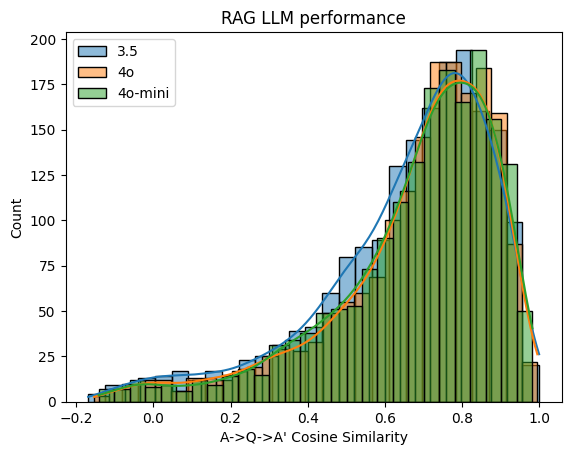

In [35]:
# !pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df_gpt35['cosine'], label='3.5', kde=True)
sns.histplot(df_gpt4o['cosine'], label='4o', kde=True)
sns.histplot(df_gpt4o_mini['cosine'], label='4o-mini', kde=True)

plt.title("RAG LLM performance")
plt.xlabel("A->Q->A' Cosine Similarity")
plt.legend()

In [36]:
'''
for parallel processing, we can use multiprocessing or joblib to compute similarities in parallel. This can speed up the computation significantly, especially if we have a large number of records to process.
'''
from tqdm.auto import tqdm

from concurrent.futures import ThreadPoolExecutor

pool = ThreadPoolExecutor(max_workers=6)

def map_progress(pool, seq, f):
    results = []

    with tqdm(total=len(seq)) as progress:
        futures = []

        for el in seq:
            future = pool.submit(f, el)
            future.add_done_callback(lambda p: progress.update())
            futures.append(future)

        for future in futures:
            result = future.result()
            results.append(result)

    return results

## LLM-As-Judge

In [37]:
prompt1_template = """
You are a precise evaluator for a Retrieval-Augmented Generation (RAG) system. Your task is to assess how well a Generated Answer conveys the same information as the Original Answer, in the context of the Generated Question.

## Inputs
- **Original Answer:** {answer_orig}
- **Generated Question:** {question}
- **Generated Answer:** {answer_llm}

## Classification Criteria
Apply exactly one label using these definitions:

| Label | Definition |
|---|---|
| `RELEVANT` | The Generated Answer captures all key facts, claims, and intent of the Original Answer. Minor wording differences are acceptable. |
| `PARTLY_RELEVANT` | The Generated Answer overlaps with the Original Answer on some key points but omits, contradicts, or distorts others. |
| `NON_RELEVANT` | The Generated Answer does not address the Original Answer's key content, is factually contradictory, or is entirely off-topic. |

## Evaluation Steps
1. Identify the key facts and claims in the Original Answer.
2. Check whether the Generated Answer covers those facts/claims accurately.
3. Note any omissions, contradictions, or additions not supported by the Original Answer.
4. Assign the label that best reflects the degree of alignment.

## Output Format
Respond only with valid JSON — no markdown, no code fences, no extra text:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Key_Points_Matched": ["<point>", "..."],
  "Key_Points_Missing_Or_Wrong": ["<point>", "..."],
  "Explanation": "<One or two sentences justifying the label based on the above.>"
}}
""".strip()


prompt2_template = """
You are a precise evaluator for a Retrieval-Augmented Generation (RAG) system. Your task is to assess how well a Generated Answer responds to the given Question — without access to any reference answer.

## Inputs
- **Question:** {question}
- **Generated Answer:** {answer_llm}

## Classification Criteria
Apply exactly one label using these definitions:

| Label | Definition |
|---|---|
| `RELEVANT` | The Generated Answer directly and completely addresses the Question. The response is on-topic and covers the core intent without significant gaps. |
| `PARTLY_RELEVANT` | The Generated Answer addresses the Question partially — it touches the topic but misses key aspects, adds significant irrelevant content, or gives a vague/hedged response where a concrete one is needed. |
| `NON_RELEVANT` | The Generated Answer does not address the Question, is off-topic, refuses to answer without justification, or contains only filler with no substantive content. |

## Evaluation Steps
1. Identify exactly what the Question is asking (topic, scope, expected detail level).
2. Determine whether the Generated Answer directly targets that ask.
3. Assess completeness: are the core aspects of the Question addressed?
4. Assign the label that best reflects how well the answer serves the question.

## Output Format
Respond only with valid JSON — no markdown, no code fences, no extra text:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Question_Intent": "<One sentence summarizing what the question is asking for.>",
  "Answer_Coverage": "<One sentence summarizing what the answer actually addresses.>",
  "Explanation": "<One or two sentences justifying the label based on the gap or alignment between the above.>"
}}
""".strip()

In [47]:
df_evaluations_aqa = pd.read_csv('/workspaces/LLM_RAG/data/evaluations-aqa.csv')
df_evaluations_aqa.head()

,Relevance,Key_Points_Matched,Key_Points_Missing_Or_Wrong,Explanation
0,RELEVANT,['The syntax for using precision_recall_fscore...,[],The Generated Answer accurately reproduces the...
1,RELEVANT,['The pickle error occurs because the custom c...,[],The Generated Answer captures all the key poin...
2,PARTLY_RELEVANT,['docker run -it --entrypoint bash <image>'],['Instructions for executing a command in an a...,The Generated Answer correctly provides the co...
3,RELEVANT,['You can make a pull request for homework sol...,[],The Generated Answer captures all the key poin...
4,NON_RELEVANT,[],['The error is related to a version mismatch i...,The Generated Answer does not address the key ...


In [55]:
df_evaluations_aqa.columns

Index(['Relevance', 'Key_Points_Matched', 'Key_Points_Missing_Or_Wrong',
       'Explanation'],
      dtype='str')

In [52]:
record = samples[0]
record

{'answer_llm': 'The syntax for using `precision_recall_fscore_support` in Python is as follows:\n\n```python\nfrom sklearn.metrics import precision_recall_fscore_support\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)\n```',
 'answer_orig': 'Scikit-learn offers another way: precision_recall_fscore_support\nExample:\nfrom sklearn.metrics import precision_recall_fscore_support\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)\n(Gopakumar Gopinathan)',
 'document': '403bbdd8',
 'question': 'What is the syntax for using precision_recall_fscore_support in Python?',
 'course': 'machine-learning-zoomcamp',
 'cosine': 0.9010756015777588}

In [41]:
prompt = prompt1_template.format(**record)
print(prompt)

You are a precise evaluator for a Retrieval-Augmented Generation (RAG) system. Your task is to assess how well a Generated Answer conveys the same information as the Original Answer, in the context of the Generated Question.

## Inputs
- **Original Answer:** Scikit-learn offers another way: precision_recall_fscore_support
Example:
from sklearn.metrics import precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)
(Gopakumar Gopinathan)
- **Generated Question:** What is the syntax for using precision_recall_fscore_support in Python?
- **Generated Answer:** The syntax for using `precision_recall_fscore_support` in Python is as follows:

```python
from sklearn.metrics import precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)
```

## Classification Criteria
Apply exactly one label using these definitions:

| Label | Definitio

In [42]:
answer = llm(prompt, model='gpt-4o')

In [62]:
# Load evaluations from the saved CSV file instead of calling the LLM
df_evaluations = pd.read_csv('data/evaluations-aqa.csv')
json_evaluations = df_evaluations.to_dict(orient='records')

In [63]:
json_evaluations = []

for i, str_eval in enumerate(evaluations):
    json_eval = json.loads(str_eval)
    json_evaluations.append(json_eval)

In [64]:

df_evaluations = pd.DataFrame(json_evaluations)

In [65]:
df_evaluations.Relevance.value_counts()

Relevance
RELEVANT           74
PARTLY_RELEVANT    64
NON_RELEVANT       12
Name: count, dtype: int64

In [66]:
df_evaluations[df_evaluations.Relevance == 'NON_RELEVANT'] #.to_dict(orient='records')

,Relevance,Key_Points_Matched,Key_Points_Missing_Or_Wrong,Explanation
4,NON_RELEVANT,[],[The error is related to a version mismatch in...,The Generated Answer discusses a Scikit-Learn ...
11,NON_RELEVANT,[],[Re-initialize by running eb init -i and choos...,The Generated Answer does not address any of t...
27,NON_RELEVANT,[],[The Original Answer provides an alternative c...,The Generated Answer fails to address the key ...
41,NON_RELEVANT,[],[The Original Answer discusses access to a rep...,The Generated Answer does not address the key ...
44,NON_RELEVANT,[],"[The Original Answer states 'Yes, it's possibl...",The Generated Answer introduces specific requi...
67,NON_RELEVANT,[],"[The Original Answer is missing, making it imp...","Without the Original Answer, it is not possibl..."
81,NON_RELEVANT,[],[The Generated Answer does not provide the con...,The Generated Answer does not address the Orig...
87,NON_RELEVANT,[],[Ensure to use sparse=True with DictVectorizer...,The Generated Answer does not address any of t...
93,NON_RELEVANT,[],[The Original Answer discusses the importance ...,The Generated Answer does not address the key ...
116,NON_RELEVANT,[],[The Original Answer discusses access to a rep...,The Generated Answer introduces Visual Studio ...


In [61]:
df_evaluations.to_csv('data/evaluations-aqa.csv', index=False)